# Part II : Cadre Logique de la Visualisation Exploratoire (EDA)

Ce notebook implémente les représentations visuelles permettant de valider les hypothèses du modèle linéaire Ridge et de détecter les anomalies physiques dans la donnée avant d'ajuster les régressions.

## Sommaire
1. **Évolution Temporelle** (KPI de vente brute + Moyennes Mobiles)
2. **Matrice de Corrélation** (Heatmap de Pearson)
3. **Diagramme de Dispersion** (Validation de la Saturation / Formes concaves)
4. **Analyse de la Dispersion** (Boxplots et Coefficient de Variation)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuration esthétique globale (Thème Premium)
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'axes.edgecolor': '#cbd5e1',
    'axes.facecolor': '#f8fafc',
    'grid.color': '#e2e8f0',
    'grid.linestyle': '--',
    'grid.alpha': 0.7,
    'figure.facecolor': '#ffffff',
    'text.color': '#1e293b',
    'axes.labelcolor': '#334155',
    'xtick.color': '#475569',
    'ytick.color': '#475569',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'legend.frameon': True,
    'legend.facecolor': '#ffffff',
    'legend.edgecolor': '#e2e8f0'
})

# Palette de couleurs harmonieuse
PALETTE = {
    'sales': '#4f46e5',        # Indigo
    'search': '#0ea5e9',       # Sky Blue
    'social': '#ec4899',       # Pink
    'display': '#10b981',      # Emerald
    'accent': '#f59e0b',       # Amber
    'neutral_dark': '#1e293b',
    'neutral_light': '#f1f5f9'
}

# 1. Chargement des données
gold_path = "../data/GoldData.csv"
df = pd.read_csv(gold_path)
df['week_start'] = pd.to_datetime(df['week_start'])

print(f"Dataset chargé avec succès ! Dimensions : {df.shape[0]} lignes, {df.shape[1]} colonnes.")
print(f"Période couverte : du {df['week_start'].min().strftime('%Y-%m-%d')} au {df['week_start'].max().strftime('%Y-%m-%d')}")

Dataset chargé avec succès ! Dimensions : 19082 lignes, 52 colonnes.
Période couverte : du 2019-07-15 au 2024-05-27


### 1. Analyse Visuelle de la Tendance et de la Saisonnalité

Nous agrégeons les ventes hebdomadaires globales pour observer le comportement de la cible `ALL_PURCHASES` dans le temps. Nous y superposons une moyenne mobile courte (4 semaines) et une tendance de fond longue (12 semaines).

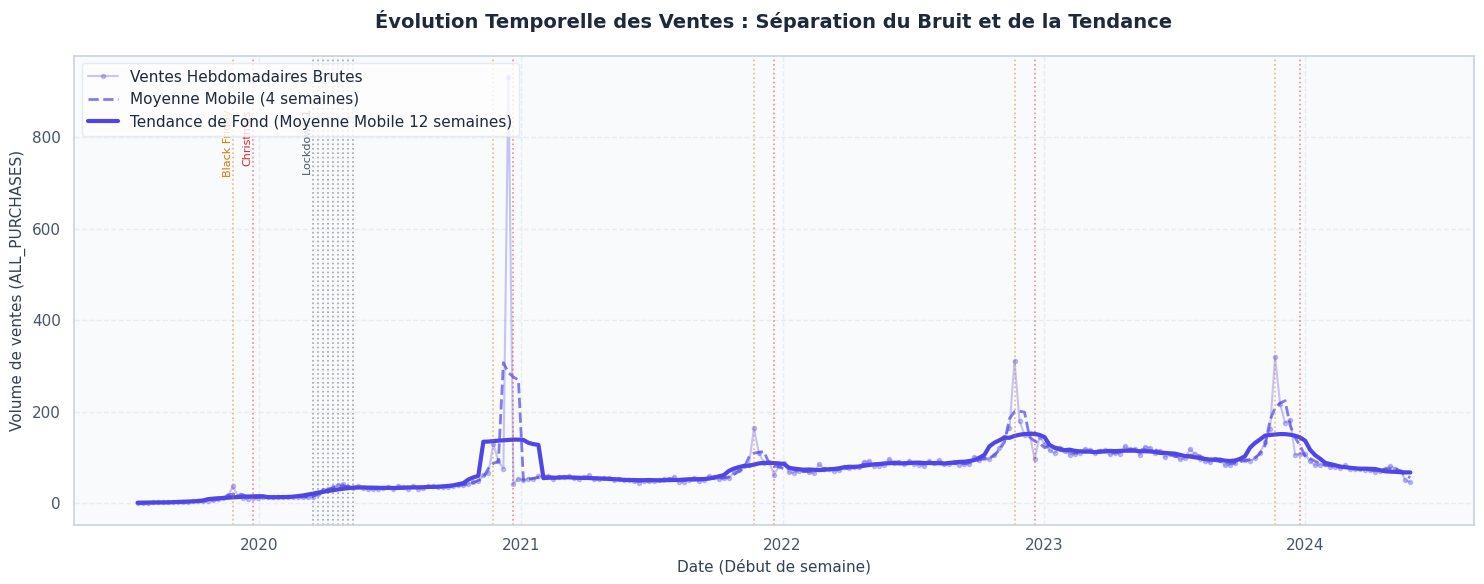

In [7]:
# Définition dynamique des agrégations selon les colonnes présentes
agg_dict = {
    'ALL_PURCHASES': 'sum',
    'PAID_SEARCH_SPEND': 'sum',
    'PAID_SOCIAL_SPEND': 'sum',
    'DISPLAY_VIDEO_SPEND': 'sum'
}

# Ajout des contrôles financiers
for col in ['ALL_PURCHASES_ORIGINAL_PRICE', 'ALL_PURCHASES_GROSS_DISCOUNT']:
    if col in df.columns:
        agg_dict[col] = 'sum'

# Ajout des événements d'exception (binaires)
event_cols = ['is_black_friday', 'is_christmas', 'is_lockdown_1', 'is_lockdown_2', 'is_lockdown_3', 'is_soldes_hiver', 'is_soldes_ete', 'is_rentree']
for col in event_cols:
    if col in df.columns:
        agg_dict[col] = 'max'

# Agrégation hebdomadaire globale (toutes séries confondues)
df_weekly = df.groupby('week_start').agg(agg_dict).reset_index()

# Calcul des moyennes mobiles
df_weekly['sales_ma_4'] = df_weekly['ALL_PURCHASES'].rolling(window=4, min_periods=1, center=True).mean()
df_weekly['sales_ma_12'] = df_weekly['ALL_PURCHASES'].rolling(window=12, min_periods=1, center=True).mean()

# Création du graphique
plt.figure(figsize=(15, 6))

# Ventes brutes
plt.plot(df_weekly['week_start'], df_weekly['ALL_PURCHASES'], 
         color=PALETTE['sales'], alpha=0.3, linewidth=1.5, 
         label='Ventes Hebdomadaires Brutes', marker='o', markersize=3)

# Moyenne mobile 4 semaines
plt.plot(df_weekly['week_start'], df_weekly['sales_ma_4'], 
         color=PALETTE['sales'], alpha=0.7, linewidth=2, linestyle='--',
         label='Moyenne Mobile (4 semaines)')

# Tendance longue (12 semaines)
plt.plot(df_weekly['week_start'], df_weekly['sales_ma_12'], 
         color=PALETTE['sales'], alpha=1.0, linewidth=3, 
         label='Tendance de Fond (Moyenne Mobile 12 semaines)')

# Annotation dynamique des événements marquants (ex: Black Friday, Soldes)
annotation_colors = {'is_black_friday': '#d97706', 'is_christmas': '#dc2626', 'is_lockdown_1': '#4b5563'}
for event in ['is_black_friday', 'is_christmas', 'is_lockdown_1']:
    if event in df_weekly.columns:
        dates = df_weekly[df_weekly[event] == 1]['week_start'].unique()
        color = annotation_colors.get(event, '#94a3b8')
        for idx, date in enumerate(dates):
            plt.axvline(pd.to_datetime(date), color=color, linestyle=':', alpha=0.5, linewidth=1.2)
            if idx == 0:  # Annoter uniquement la première occurrence pour ne pas surcharger
                plt.text(pd.to_datetime(date), plt.gca().get_ylim()[1]*0.88, event.replace('is_', '').replace('_', ' ').title(), 
                         color=color, fontsize=8, rotation=90, ha='right', va='top')

plt.title("Évolution Temporelle des Ventes : Séparation du Bruit et de la Tendance", pad=20)
plt.xlabel("Date (Début de semaine)")
plt.ylabel("Volume de ventes (ALL_PURCHASES)")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

### 2. Matrice de Corrélation Graphique (Heatmap)

Nous traquons les relations linéaires directes entre la cible et les dépenses médias, ainsi que le risque de colinéarité entre variables explicatives (corrélations > 0.8).

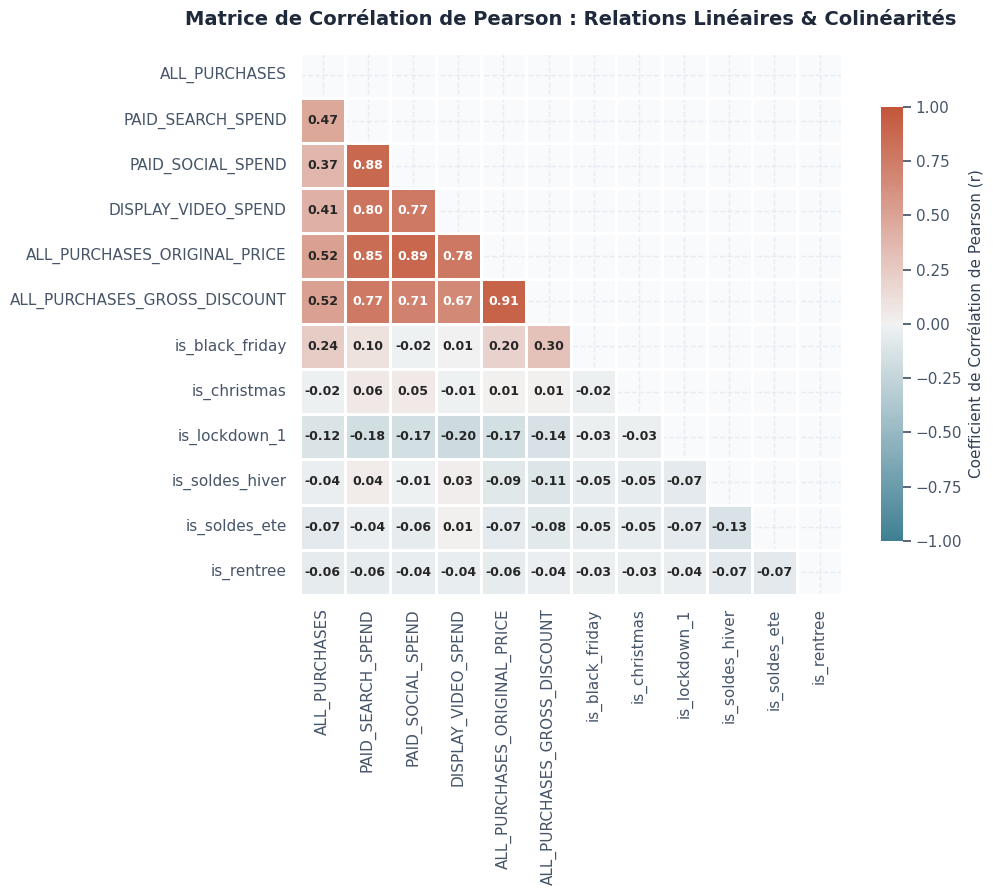

Recherche de colinéarités fortes (abs(r) > 0.8) entre variables explicatives :
  ⚠️ Forte colinéarité entre 'PAID_SEARCH_SPEND' et 'PAID_SOCIAL_SPEND' : r = 0.88
  ⚠️ Forte colinéarité entre 'PAID_SEARCH_SPEND' et 'ALL_PURCHASES_ORIGINAL_PRICE' : r = 0.85
  ⚠️ Forte colinéarité entre 'PAID_SOCIAL_SPEND' et 'ALL_PURCHASES_ORIGINAL_PRICE' : r = 0.89
  ⚠️ Forte colinéarité entre 'ALL_PURCHASES_ORIGINAL_PRICE' et 'ALL_PURCHASES_GROSS_DISCOUNT' : r = 0.91


In [8]:
# Sélection dynamique des colonnes de corrélation selon leur présence dans df_weekly
target_var = 'ALL_PURCHASES'
media_vars = ['PAID_SEARCH_SPEND', 'PAID_SOCIAL_SPEND', 'DISPLAY_VIDEO_SPEND']

potential_controls = [
    'ALL_PURCHASES_ORIGINAL_PRICE', 
    'ALL_PURCHASES_GROSS_DISCOUNT', 
    'is_black_friday', 
    'is_christmas',
    'is_lockdown_1',
    'is_soldes_hiver',
    'is_soldes_ete',
    'is_rentree'
]

control_vars = [col for col in potential_controls if col in df_weekly.columns]
corr_cols = [target_var] + media_vars + control_vars

corr_matrix = df_weekly[corr_cols].corr(method='pearson')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True, 
            fmt=".2f", 
            cmap=sns.diverging_palette(220, 20, as_cmap=True),
            vmin=-1, vmax=1, center=0,
            square=True, 
            linewidths=.8, 
            cbar_kws={"shrink": .8, "label": "Coefficient de Corrélation de Pearson (r)"},
            annot_kws={"size": 9, "weight": "bold"})

plt.title("Matrice de Corrélation de Pearson : Relations Linéaires & Colinéarités", pad=20)
plt.tight_layout()
plt.show()

# Alerte colinéarité
print("Recherche de colinéarités fortes (abs(r) > 0.8) entre variables explicatives :")
colinear_found = False
for i in range(len(corr_cols)):
    for j in range(i+1, len(corr_cols)):
        col_i = corr_cols[i]
        col_j = corr_cols[j]
        # Ne pas comparer la cible (ventes) avec les variables explicatives pour la colinéarité explicative
        if col_i == target_var:
            continue
        r_val = corr_matrix.loc[col_i, col_j]
        if abs(r_val) > 0.8:
            colinear_found = True
            print(f"  ⚠️ Forte colinéarité entre '{col_i}' et '{col_j}' : r = {r_val:.2f}")
if not colinear_found:
    print("  ✅ Aucune colinéarité critique (> 0.8) détectée entre les variables explicatives.")

### 3. Diagramme de Dispersion (Saturation / Formes)

Nous vérifions si la relation entre les dépenses marketing et les ventes est linéaire ou concave. Une relation concave valide la théorie économique des rendements décroissants et nécessite une transformation non-linéaire (ex: Hill ou Log).

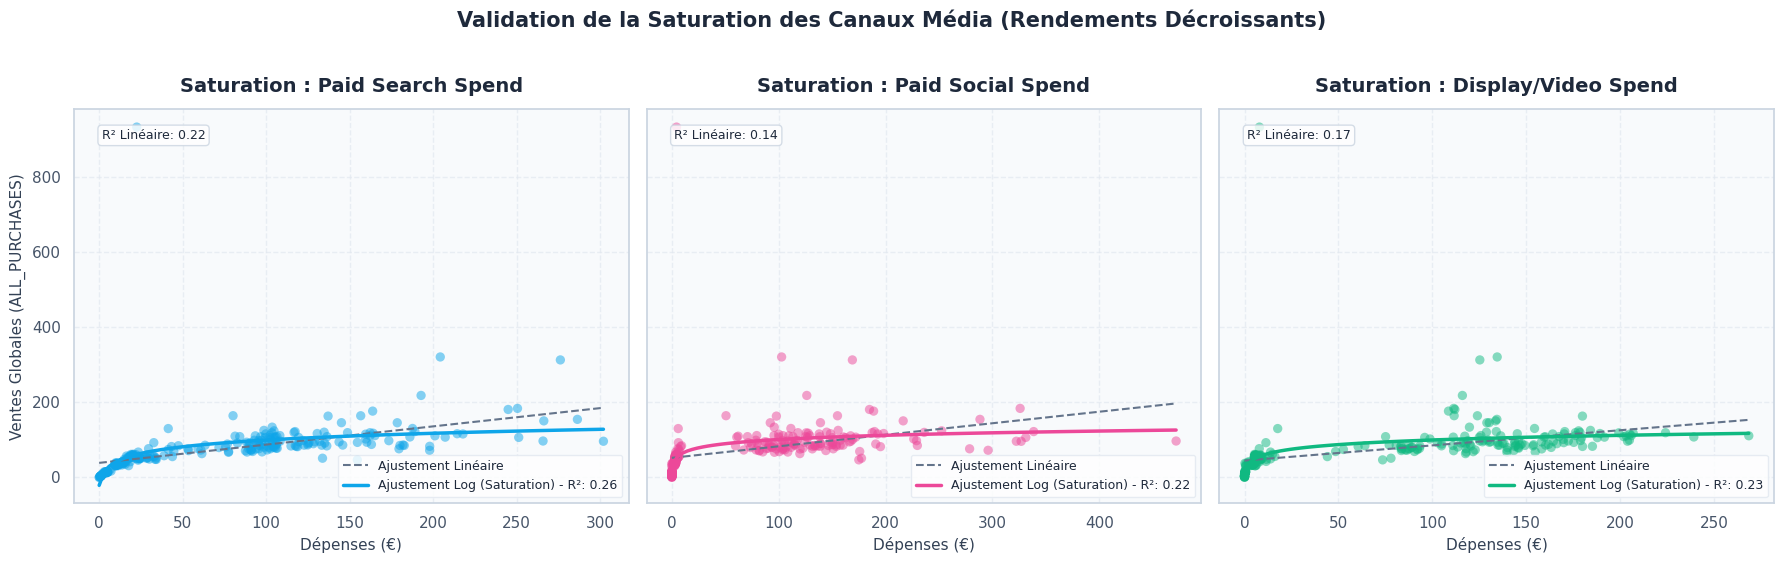

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)

media_channels = {
    'PAID_SEARCH_SPEND': ('Paid Search Spend', PALETTE['search']),
    'PAID_SOCIAL_SPEND': ('Paid Social Spend', PALETTE['social']),
    'DISPLAY_VIDEO_SPEND': ('Display/Video Spend', PALETTE['display'])
}

for i, (col, (label, color)) in enumerate(media_channels.items()):
    ax = axes[i]
    x = df_weekly[col]
    y = df_weekly['ALL_PURCHASES']
    
    # Scatter
    ax.scatter(x, y, color=color, alpha=0.5, edgecolors='none', s=45)
    
    # Regression Linéaire simple
    slope, intercept, r_lin, p_val, std_err = stats.linregress(x, y)
    x_range = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_range, slope * x_range + intercept, color='#64748b', linestyle='--', linewidth=1.5, label='Ajustement Linéaire')
    
    # Regression Logarithmique (Saturation)
    log_x = np.log1p(x)
    slope_log, intercept_log, r_log, p_log, std_err_log = stats.linregress(log_x, y)
    y_log_pred = slope_log * np.log1p(x_range) + intercept_log
    
    ax.plot(x_range, y_log_pred, color=color, linewidth=2.5, 
            label=f'Ajustement Log (Saturation) - R²: {r_log**2:.2f}')
    
    ax.set_title(f"Saturation : {label}", pad=12)
    ax.set_xlabel("Dépenses (€)")
    if i == 0:
        ax.set_ylabel("Ventes Globales (ALL_PURCHASES)")
    ax.legend(loc='lower right', fontsize=9)
    
    # Boîte statistique R² linéaire
    ax.text(0.05, 0.95, f"R² Linéaire: {r_lin**2:.2f}", transform=ax.transAxes, 
            fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffffff', edgecolor='#cbd5e1', alpha=0.8))

plt.suptitle("Validation de la Saturation des Canaux Média (Rendements Décroissants)", fontsize=15, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4. Analyse de la Dispersion et de la Variation du Spend (Boxplots)

Si un budget média ne varie pas d'une semaine sur l'autre (absence de variance), la régression Ridge sera incapable de dissocier son effet réel sur les ventes de l'effet de base (Intercept). Nous traquons le Coefficient de Variation ($CV = \sigma / \mu$).

C:\Users\saady\AppData\Local\Temp\ipykernel_32616\1637214267.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([media_channels[c][0] for c in df_spends.columns])


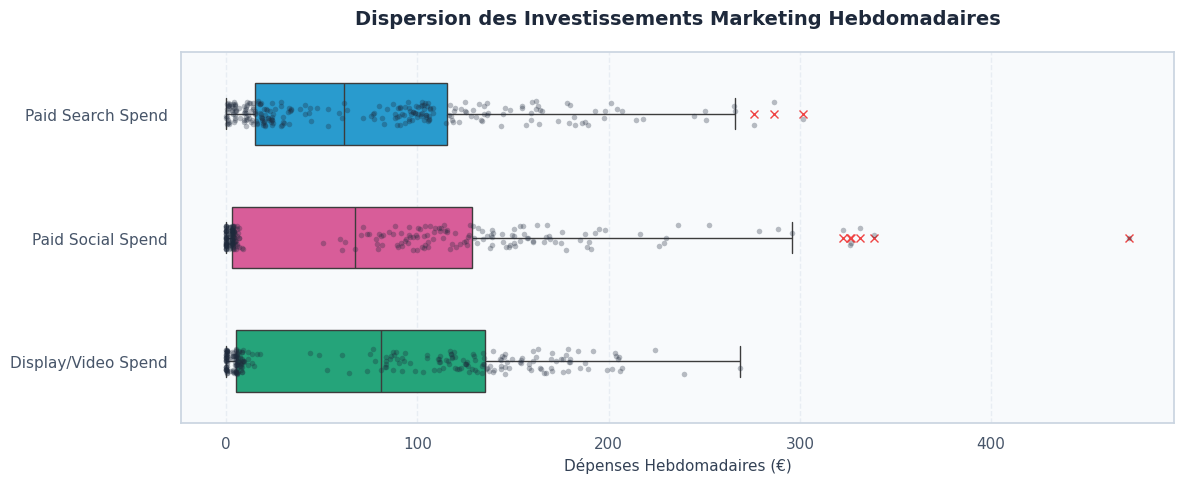

Évaluation de la variance des canaux (Signal Statistique) :
- Paid Search Spend :
  * Moyenne : 74.83 € | Écart-type : 68.49 €
  * Coefficient de Variation (CV) : 0.915 | Statut : ✅ Signal de Variance Suffisant
- Paid Social Spend :
  * Moyenne : 74.83 € | Écart-type : 84.70 €
  * Coefficient de Variation (CV) : 1.132 | Statut : ✅ Signal de Variance Suffisant
- Display/Video Spend :
  * Moyenne : 74.83 € | Écart-type : 71.88 €
  * Coefficient de Variation (CV) : 0.961 | Statut : ✅ Signal de Variance Suffisant


In [10]:
plt.figure(figsize=(12, 5))
df_spends = df_weekly[list(media_channels.keys())]

# Boxplot horizontal
ax = sns.boxplot(data=df_spends, orient='h', palette=[PALETTE['search'], PALETTE['social'], PALETTE['display']], width=0.5,
                flierprops=dict(marker="x", markerfacecolor="#ef4444", markeredgecolor="#ef4444"))

# Stripplot
sns.stripplot(data=df_spends, orient='h', color=PALETTE['neutral_dark'], size=4, alpha=0.3, jitter=0.1, ax=ax)

plt.title("Dispersion des Investissements Marketing Hebdomadaires", pad=20)
plt.xlabel("Dépenses Hebdomadaires (€)")
ax.set_yticklabels([media_channels[c][0] for c in df_spends.columns])
plt.tight_layout()
plt.show()

# Calcul du CV
print("Évaluation de la variance des canaux (Signal Statistique) :")
for col in df_spends.columns:
    mean_val = df_spends[col].mean()
    std_val = df_spends[col].std()
    cv = std_val / mean_val if mean_val > 0 else 0
    
    status = "✅ Signal de Variance Suffisant" if cv >= 0.2 else "⚠️ Risque d'Instabilité (Budget trop constant)"
    print(f"- {media_channels[col][0]} :")
    print(f"  * Moyenne : {mean_val:.2f} € | Écart-type : {std_val:.2f} €")
    print(f"  * Coefficient de Variation (CV) : {cv:.3f} | Statut : {status}")